<a href="https://colab.research.google.com/github/RaulGadirov/house-price-prediction/blob/main/RaulProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Salam, mənim layihəm evlərin satış qiymətinin proqnozlaşdırılmasına həsr olunub. Bu bir reqressiya məsələsidir — məqsəd evin sahəsi, otaq sayı, mərtəbə sayı və digər xüsusiyyətlərinə əsasən qiymətini proqnozlaşdıran model qurmaqdır.


In [ ]:
df = pd.read_csv("/content/sample_data/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


In [ ]:
for i in df.columns.drop(["price", "area"]):
    print(f"{i} : {df[i].unique()}")

bedrooms : [4 3 5 2 6 1]
bathrooms : [2 4 1 3]
stories : [3 4 2 1]
mainroad : ['yes' 'no']
guestroom : ['no' 'yes']
basement : ['no' 'yes']
hotwaterheating : ['no' 'yes']
airconditioning : ['yes' 'no']
parking : [2 3 0 1]
prefarea : ['yes' 'no']
furnishingstatus : ['furnished' 'semi-furnished' 'unfurnished']


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='area', ylabel='price'>

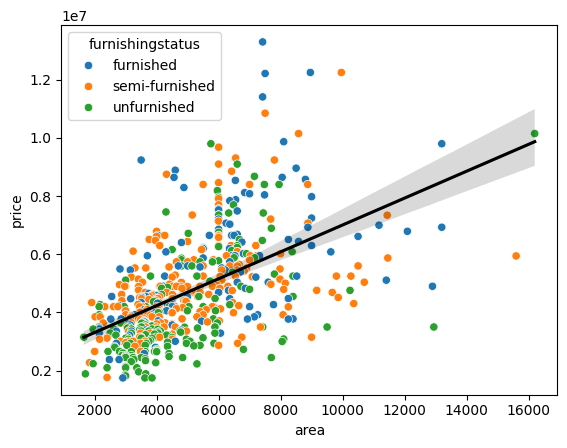

In [ ]:
sns.scatterplot(x='area', y='price', data=df,hue="furnishingstatus")
sns.regplot(x='area', y='price', data=df, scatter=False, color='black')

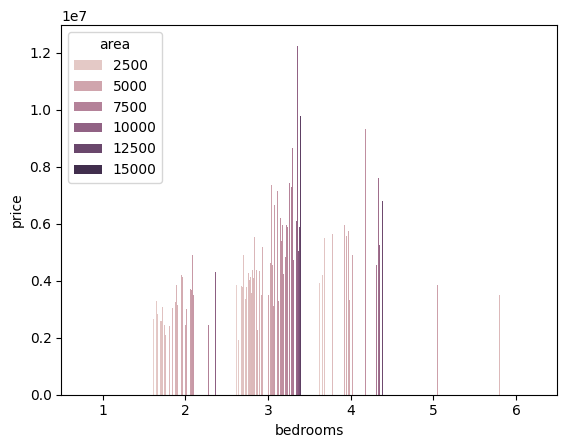

In [ ]:
look = df.groupby(["bedrooms","area"])["price"].mean().reset_index()
sns.barplot(data=look, x="bedrooms", y="price", hue="area")
plt.show()

Böyük sahəyə malik 3 otaqlı evlər, kiçik sahəyə malik 4 otaqlı evlərdən orta hesabla daha bahadır — bu, sahənin qiymətə otaq sayından daha çox təsir etdiyini göstərir


In [ ]:
df.rename(columns={"stories":"floors"},inplace=True)

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,floors,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)


In [ ]:
df

,price,area,bedrooms,bathrooms,floors,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,False,True
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,True,False
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,False,True
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,False,False


In [ ]:
df[["furnishingstatus_semi-furnished","furnishingstatus_unfurnished"]] = df[["furnishingstatus_semi-furnished","furnishingstatus_unfurnished"]].astype("int64")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   floors                           545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from skopt import BayesSearchCV
search = BayesSearchCV(
    RandomForestRegressor(random_state=50),
    {
        "n_estimators": (50, 200),
        "max_depth": (2, 10)
    },
    n_iter=10,
    cv=5,
    random_state=50
)
search.fit(X_train_scaled, y_train)
print("Best parameters:", search.best_params_)
print("Best score:", search.best_score_)


Best parameters: OrderedDict({'max_depth': 8, 'n_estimators': 198})
Best score: 0.5731750587015498


In [ ]:
random_model = RandomForestRegressor(n_estimators=198, max_depth=8, random_state=50)
random_model.fit(X_train_scaled, y_train)
random_pred = random_model.predict(X_test_scaled)

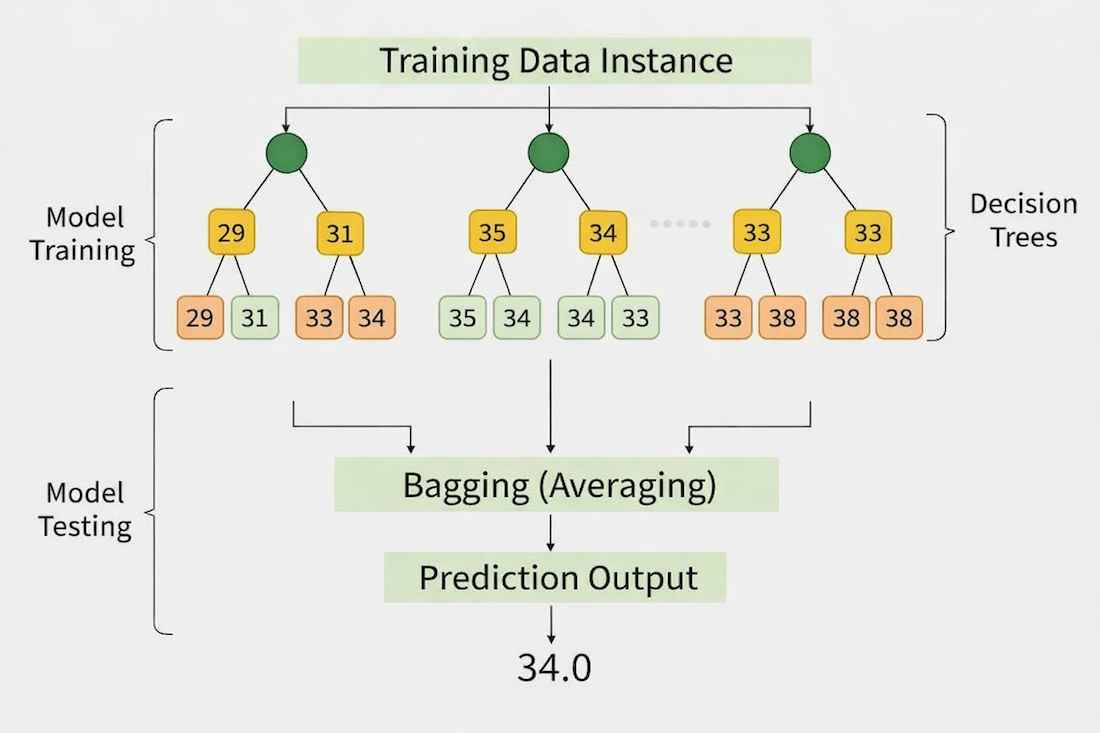



In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_pred = lin_model.predict(X_test_scaled)

In [ ]:
lin_mae = mean_absolute_error(y_test, lin_pred)
random_mae = mean_absolute_error(y_test, random_pred)
print(f"Linear Regression MAE: {lin_mae}")
print(f"Random Forest MAE: {random_mae}")

Linear Regression MAE: 736886.1661127878
Random Forest MAE: 712655.3093698916


In [ ]:
lin_mse = mean_squared_error(y_test, lin_pred)
random_mse = mean_squared_error(y_test, random_pred)
print(f"Linear Regression MSE: {lin_mse}")
print(f"Random Forest MSE: {random_mse}")

Linear Regression MSE: 829690385060.858
Random Forest MSE: 854755420969.2113


In [ ]:
lin_rmse = np.sqrt(lin_mse)
random_rmse = np.sqrt(random_mse)
print(f"Linear Regression RMSE: {lin_rmse}")
print(f"Random Forest RMSE: {random_rmse}")

Linear Regression RMSE: 910873.4187914685
Random Forest RMSE: 924529.8377928163


In [ ]:
lin_r2 = r2_score(y_test, lin_pred)
random_r2 = r2_score(y_test, random_pred)
print(f"Linear Regression R^2: {lin_r2}")
print(f"Random Forest R^2: {random_r2}")

Linear Regression R^2: 0.7560355994624842
Random Forest R^2: 0.7486654086419842


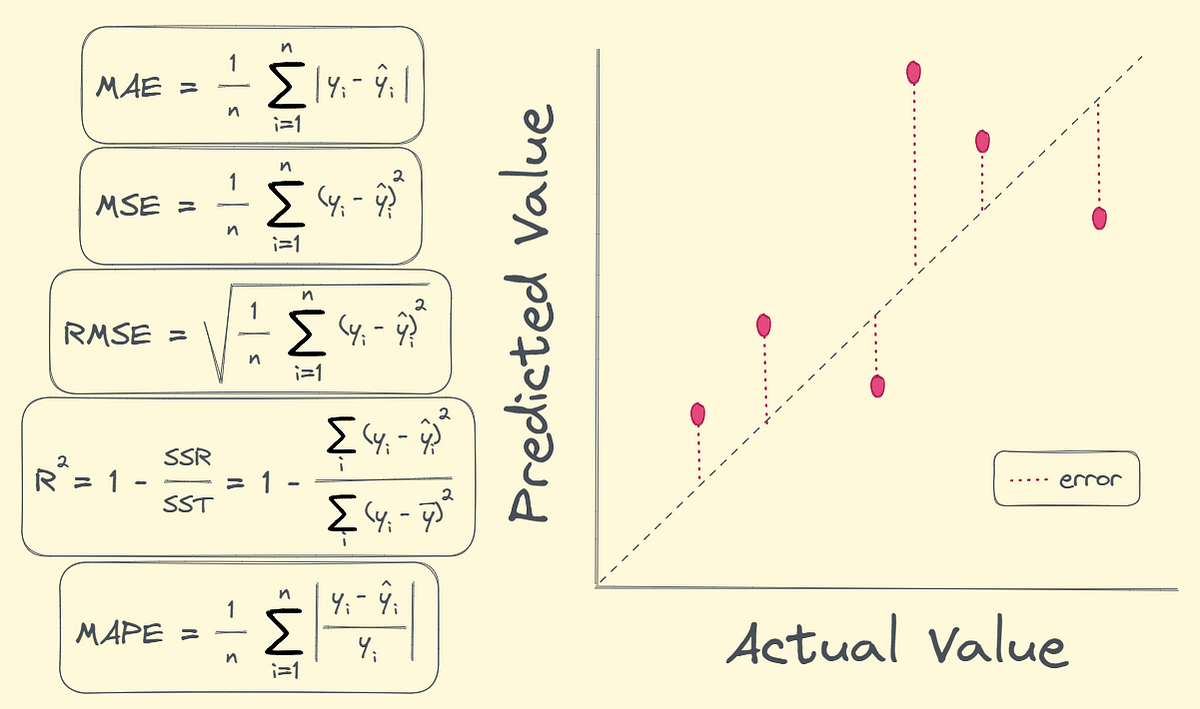

In [ ]:
comparison_df = pd.DataFrame({
    "Actual price": y_test,
    "Linear Model ": lin_pred,
    "Random Forest": random_pred
})
comparison_df.head()

,Actual price,Linear Model,Random Forest
333,3920000,3488198.28,3479934.57
37,7980000,8346828.14,8472995.76
396,3500000,3345681.02,3738210.75
494,2730000,3365453.54,3859885.14
536,1960000,2850910.60,2974966.69


In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Linear Model Metrics": [lin_mae, lin_mse, lin_rmse, lin_r2],
    "RandomForest Metrics": [random_mae, random_mse, random_rmse, random_r2]
})
metrics_df

,Metric,Linear Model Metrics,RandomForest Metrics
0,MAE,736886.17,712655.31
1,MSE,829690385060.86,854755420969.21
2,RMSE,910873.42,924529.84
3,R2,0.76,0.75


Linear Model >RandomForest